In [1]:
import sys
import os
import matplotlib.pyplot as plt
import cv2

import numpy as np

# Add the src directory to the path. TEMPORARY FIX
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../../..")))

from src.data_processing.dataset_loader import CoastData

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors


In [2]:
data_path_oblique_registered = os.path.abspath(os.path.join(os.getcwd(), "../../../data/SCLabels_oblique_registered_v1.0.0/"))
data_path_oblique = os.path.abspath(os.path.join(os.getcwd(), "../../../data/SCLabels_oblique_v1.0.0/"))
data_path_rectified = os.path.abspath(os.path.join(os.getcwd(), "../../../data/SCLabels_v1.0.0/"))

station_name = "arenaldentem"
data = {
    "oblique_registered": CoastData(data_path_oblique_registered, name=station_name),
    "oblique": CoastData(data_path_oblique, name=station_name),
    "rectified": CoastData(data_path_rectified, name=station_name)
}

index = 0  # Index of the image to load

# Olbique registered image
path_oblique_registered = data["oblique_registered"].get_images(get_mask=False)[index]
print(path_oblique_registered)
image_oblique_registered = cv2.imread(path_oblique_registered['image'])
image_oblique_registered = cv2.cvtColor(image_oblique_registered, cv2.COLOR_BGR2RGB)

# Oblique image and mask
path_oblique = data["oblique"].get_images(get_mask=True)[index]
print(path_oblique)
image_oblique = cv2.imread(path_oblique['image'])
image_oblique = cv2.cvtColor(image_oblique, cv2.COLOR_BGR2RGB)
mask_oblique = cv2.imread(path_oblique['mask'], cv2.IMREAD_GRAYSCALE)

# Rectified image and mask
path_rectified = data["rectified"].get_images(get_mask=True)[index]
print(path_rectified)
image_rectified = cv2.imread(path_rectified['image'])
image_rectified = cv2.cvtColor(image_rectified, cv2.COLOR_BGR2RGB)
mask_rectified = cv2.imread(path_rectified['mask'], cv2.IMREAD_GRAYSCALE)

CoastData: arenaldentem - 40 images
CoastData: arenaldentem - 40 images
CoastData: arenaldentem - 40 images
{'image': 'c:\\Users\\josep\\Documents\\SOCIB\\Shoreline-extraction\\data\\SCLabels_oblique_registered_v1.0.0\\images\\1661756929.Mon.Aug.29_08_08_49.CET.2022.arenaldentem.image.jpg'}
{'image': 'c:\\Users\\josep\\Documents\\SOCIB\\Shoreline-extraction\\data\\SCLabels_oblique_v1.0.0\\images\\1661756929.Mon.Aug.29_08_08_49.CET.2022.arenaldentem.image.jpg', 'mask': 'c:\\Users\\josep\\Documents\\SOCIB\\Shoreline-extraction\\data\\SCLabels_oblique_v1.0.0\\masks\\1661756929.Mon.Aug.29_08_08_49.CET.2022.arenaldentem.mask.png'}
{'image': 'c:\\Users\\josep\\Documents\\SOCIB\\Shoreline-extraction\\data\\SCLabels_v1.0.0\\images\\1661756929.Mon.Aug.29_08_08_49.CET.2022.arenaldentem.image.jpg', 'mask': 'c:\\Users\\josep\\Documents\\SOCIB\\Shoreline-extraction\\data\\SCLabels_v1.0.0\\masks\\1661756929.Mon.Aug.29_08_08_49.CET.2022.arenaldentem.mask.png'}


In [5]:
# color_map_hex = {
#     'NoData': '#000000',       
#     'NotClassified': '#727272',
#     'Landwards': '#D2B48C',    
#     'Seawards': '#3434E7',     
#     'Shoreline': '#00FF00'     
# }

color_map_hex = {
    'NoData': '#000000',       
    'NotClassified': '#727272',
    'Landwards': '#8B4513',    
    'Seawards': '#0000FF',     
    'Shoreline': '#00FF00'     
}

classes_ordered = ['NoData', 'NotClassified', 'Landwards', 'Seawards', 'Shoreline']
colors_list = [color_map_hex[c] for c in classes_ordered]
cmap = mcolors.ListedColormap(colors_list)

bounds = [-1, 10, 50, 110, 200, 260]
norm = mcolors.BoundaryNorm(bounds, cmap.N)

def add_border(ax):
    ax.axis('on')
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(0.2)

def add_label(ax, text, x = 0.015, y = 0.92):
    ax.text(
        x, y, text, # Coordenades x, y (0 a 1)
        transform=ax.transAxes, # Important: relatiu als eixos, no píxels
        color='white', 
        fontsize=9, 
        fontweight='bold', 
        va='top', ha='left',
        bbox=dict(facecolor='black', alpha=0.5, edgecolor='none', boxstyle='square,pad=0.2')

        # fontsize=9, color='white', weight='bold',
        #   bbox=dict(facecolor='black', alpha=0.5, edgecolor='none', boxstyle='round,pad=0.2')
    )

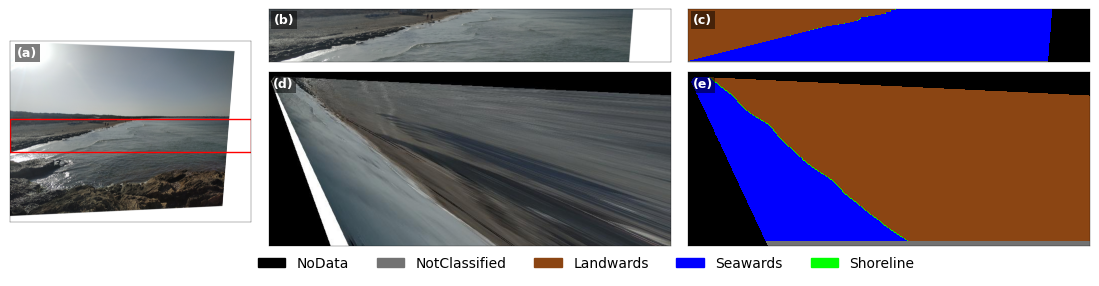

In [6]:
fig = plt.figure(figsize=(12, 2.8)) 
gs = fig.add_gridspec(2, 3, width_ratios=[0.6, 1, 1], height_ratios=[1, 3.5])

ax_context = fig.add_subplot(gs[:, 0])
ax_context.imshow(image_oblique_registered)
add_label(ax_context, "(a)", x=0.03, y=0.97)
add_border(ax_context)

# ROI
max_width = image_oblique_registered.shape[1]
rect = patches.Rectangle((5, 1285), max_width-10, 550, linewidth=1, edgecolor='red', facecolor='none')
ax_context.add_patch(rect)

ax_obl_img = fig.add_subplot(gs[0, 1])
ax_obl_img.imshow(image_oblique)
add_label(ax_obl_img, "(b)", x=0.013, y=0.92)
add_border(ax_obl_img)

ax_obl_mask = fig.add_subplot(gs[0, 2])
ax_obl_mask.imshow(mask_oblique, cmap=cmap, norm=norm, interpolation='nearest')
add_label(ax_obl_mask, "(c)", x=0.013, y=0.92)
add_border(ax_obl_mask)

ax_rect_img = fig.add_subplot(gs[1, 1])
ax_rect_img.imshow(image_rectified)
add_label(ax_rect_img, "(d)", x=0.011, y=0.97)
add_border(ax_rect_img) 

ax_rect_mask = fig.add_subplot(gs[1, 2])
ax_rect_mask.imshow(mask_rectified, cmap=cmap, norm=norm, interpolation='nearest')
add_label(ax_rect_mask, "(e)", x=0.011, y=0.97)
add_border(ax_rect_mask)

legend_patches = [
    mpatches.Patch(color=color_map_hex[c], label=c) for c in classes_ordered
]

fig.legend(handles=legend_patches, 
           loc='lower center', 
           ncol=5,  
           bbox_to_anchor=(0.53, 0.02), 
           fontsize=10, 
           frameon=False)

plt.subplots_adjust(top=1, bottom=0.12, left=0.05, right=0.95, hspace=0.00, wspace=0.05)

plt.show()

dpi = 300
fig.savefig(os.path.join("img", "example_image_and_mask_oblique_registered.png"), bbox_inches='tight', dpi=dpi)
fig.savefig(os.path.join("pdf", "example_image_and_mask_oblique_registered.pdf"), bbox_inches='tight', dpi=dpi)
fig.savefig(os.path.join("svg", "example_image_and_mask_oblique_registered.svg"), bbox_inches='tight', dpi=dpi)
fig.savefig(os.path.join("tiff", "example_image_and_mask_oblique_registered.tiff"), bbox_inches='tight', dpi=600, pil_kwargs={"compression": "tiff_lzw"})

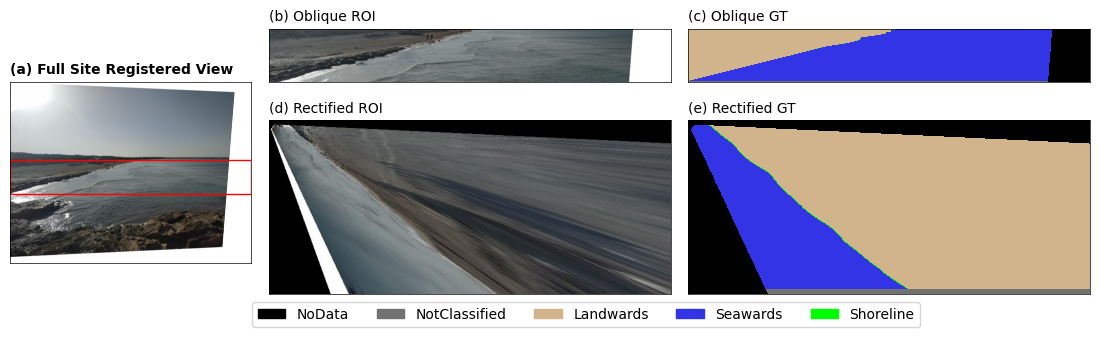

In [71]:
fig = plt.figure(figsize=(12, 3.4)) 
gs = fig.add_gridspec(2, 3, width_ratios=[0.6, 1, 1], height_ratios=[1, 4])

ax_context = fig.add_subplot(gs[:, 0])
ax_context.imshow(image_oblique_registered)
ax_context.set_title("(a) Full Site Registered View", loc='left', fontweight='bold', fontsize=10)
add_border(ax_context)

# ROI
max_width = image_oblique_registered.shape[1]
rect = patches.Rectangle((2, 1300), max_width-2, 550, linewidth=1, edgecolor='red', facecolor='none')
ax_context.add_patch(rect)

ax_obl_img = fig.add_subplot(gs[0, 1])
ax_obl_img.imshow(image_oblique)
ax_obl_img.set_title("(b) Oblique ROI", loc='left', fontsize=10)
add_border(ax_obl_img)

ax_obl_mask = fig.add_subplot(gs[0, 2])
ax_obl_mask.imshow(mask_oblique, cmap=cmap, norm=norm, interpolation='nearest')
ax_obl_mask.set_title("(c) Oblique GT", loc='left', fontsize=10)
add_border(ax_obl_mask)

ax_rect_img = fig.add_subplot(gs[1, 1])
ax_rect_img.imshow(image_rectified)
ax_rect_img.set_title("(d) Rectified ROI", loc='left', fontsize=10)
add_border(ax_rect_img) 

ax_rect_mask = fig.add_subplot(gs[1, 2])
ax_rect_mask.imshow(mask_rectified, cmap=cmap, norm=norm, interpolation='nearest')
ax_rect_mask.set_title("(e) Rectified GT", loc='left', fontsize=10)
add_border(ax_rect_mask)

legend_patches = [
    mpatches.Patch(color=color_map_hex[c], label=c) for c in classes_ordered
]

fig.legend(handles=legend_patches, 
           loc='lower center', 
           ncol=5, 
           bbox_to_anchor=(0.53, 0.02), 
           fontsize=10, 
           frameon=True)

plt.subplots_adjust(top=0.92, bottom=0.07, left=0.05, right=0.95, hspace=0.1, wspace=0.05)
plt.show()

dpi = 300
fig.savefig(os.path.join("img", "example_image_and_mask_oblique_registered.png"), bbox_inches='tight', dpi=dpi)
fig.savefig(os.path.join("pdf", "example_image_and_mask_oblique_registered.pdf"), bbox_inches='tight', dpi=dpi)
fig.savefig(os.path.join("svg", "example_image_and_mask_oblique_registered.svg"), bbox_inches='tight', dpi=dpi)
fig.savefig(os.path.join("tiff", "example_image_and_mask_oblique_registered.tiff"), bbox_inches='tight', dpi=600, pil_kwargs={"compression": "tiff_lzw"})